# Hyperparameter Validation Curves

Train vs test RMSE as a single hyperparameter is swept, holding everything else at the pipeline's default config. A rising gap between the two lines (train error kept dropping, test error plateaued or rose) signals overfitting at that setting.

Run this notebook via `kedro jupyter notebook` (or `kedro jupyter lab`) from the project root so the `catalog` variable is available.

In [1]:
%load_ext kedro.ipython

[08/17/26 05:26:39] INFO     Using                                                                  ]8;id=10726013;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=10726014;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/framework/project/__init__.py#302\302]8;;\
                             '/opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/framew                
                             ork/project/rich_logging.yml' as logging configuration.                               

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=10726021;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=10726022;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py#67\67]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=10726028;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=10726029;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py#69\69]8;;\

                    INFO     Resolved project path as:                                              ]8;id=10726035;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=10726036;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py#193\193]8;;\
                             /workspaces/dh-food-delivery-time/model_pipeline.                                     
                             To set a different path, run '%reload_kedro <project_root>'                           

[08/17/26 05:26:43] WARNING  /opt/conda/envs/deliveryenv/lib/python3.12/site-packages/tqdm/auto.py: ]8;id=10726043;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=10726044;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py#112\112]8;;\
                             21: TqdmWarning: IProgress not found. Please update jupyter and                       
                             ipywidgets. See                                                                       
                             https://ipywidgets.readthedocs.io/en/stable/user_install.html                         
                               from .autonotebook import tqdm as notebook_tqdm                                     
                                                                                                                   

[08/17/26 05:26:44] INFO     No typed parameter requirements found, returning original   ]8;id=10726051;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/validation/parameter_validator.py\parameter_validator.py]8;;\:]8;id=10726052;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/validation/parameter_validator.py#124\124]8;;\
                             parameters                                                                            

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=10726059;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro_telemetry/plugin.py\plugin.py]8;;\:]8;id=10726060;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro_telemetry/plugin.py#273\273]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

                    INFO     Kedro project model_pipeline                                           ]8;id=10726066;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=10726067;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py#159\159]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=10726073;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=10726074;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/ipython/__init__.py#160\160]8;;\
                             'pipelines'                                                                           

In [2]:
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import root_mean_squared_error

from model_pipeline.pipelines.model_pipeline.nodes import (
    _build_random_forest,
    _build_xgboost,
    _build_catboost,
    _extract_target,
)

In [3]:
parameters = catalog.load("params:model_options")

X_train_encoded = catalog.load("modin_train_encoded_categorical")
X_test_encoded = catalog.load("modin_test_encoded_categorical")
X_train_native = catalog.load("modin_train_native_categorical")
X_test_native = catalog.load("modin_test_native_categorical")

y_train = _extract_target(catalog.load("fea_train_tgt"), parameters)
y_test = _extract_target(catalog.load("fea_test_tgt"), parameters)


def _build_lasso(parameters):
    """Plain (non-CV) Lasso -- alpha is swept manually here, not selected by CV."""
    return Lasso(random_state=parameters["random_state"])

                    INFO     Loading data from params:model_options (MemoryDataset)...         ]8;id=10726081;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=10726082;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

                    INFO     Loading data from modin_train_encoded_categorical (CSVDataset)... ]8;id=10726087;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=10726088;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

                    INFO     Loading data from modin_test_encoded_categorical (CSVDataset)...  ]8;id=10726093;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=10726094;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

                    INFO     Loading data from modin_train_native_categorical                  ]8;id=10726099;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=10726100;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\
                             (ParquetDataset)...                                                                   

                    INFO     Loading data from modin_test_native_categorical                   ]8;id=10726105;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=10726106;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\
                             (ParquetDataset)...                                                                   

                    INFO     Loading data from fea_train_tgt (CSVDataset)...                   ]8;id=10726111;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=10726112;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

                    INFO     Loading data from fea_test_tgt (CSVDataset)...                    ]8;id=10726117;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=10726118;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

In [4]:
def plot_train_test_error_curve(
    model_name,
    build_model,
    param_name,
    param_values,
    X_train,
    X_test,
    log_x=False,
):
    """Plot train vs test RMSE as a single hyperparameter is varied.

    build_model(parameters) supplies a fresh unfitted estimator with the
    pipeline's real training config (random_state, cat_features,
    enable_categorical, etc.); only param_name is overridden per point, so
    the sweep reflects the same model the pipeline actually trains.
    """
    train_errors, test_errors = [], []

    for value in param_values:
        model = build_model(parameters)
        model.set_params(**{param_name: value})
        model.fit(X_train, y_train)

        train_errors.append(root_mean_squared_error(y_train, model.predict(X_train)))
        test_errors.append(root_mean_squared_error(y_test, model.predict(X_test)))

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(param_values, train_errors, marker="o", label="Train RMSE")
    ax.plot(param_values, test_errors, marker="o", label="Test RMSE")
    if log_x:
        ax.set_xscale("log")
    ax.set_xlabel(param_name)
    ax.set_ylabel("RMSE (min)")
    ax.set_title(f"{model_name}: Train vs Test RMSE by {param_name}")
    ax.legend()
    fig.tight_layout()
    plt.show()

## Random Forest

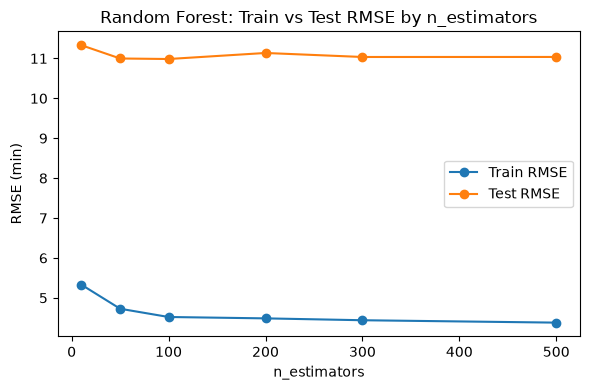

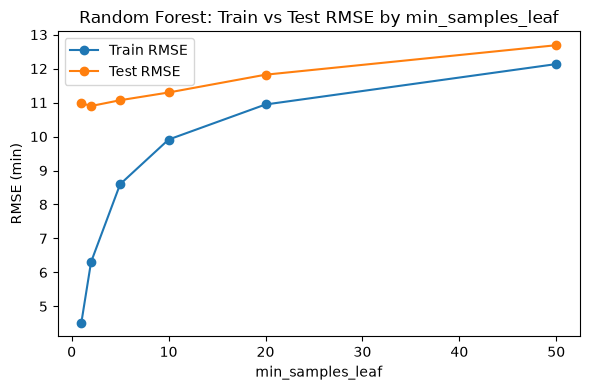

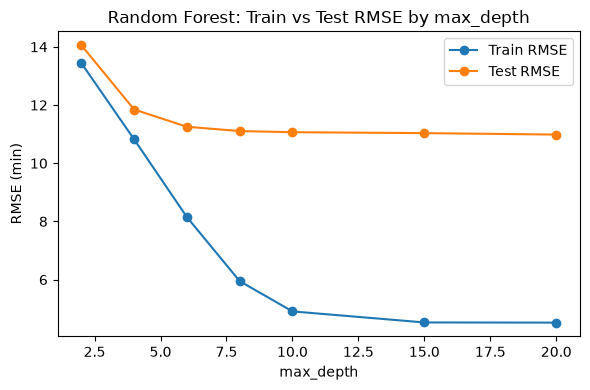

In [10]:
plot_train_test_error_curve(
    "Random Forest", _build_random_forest, "n_estimators",
    [10, 50, 100, 200, 300, 500], X_train_encoded, X_test_encoded,
)
plot_train_test_error_curve(
    "Random Forest", _build_random_forest, "min_samples_leaf",
    [1, 2, 5, 10, 20, 50], X_train_encoded, X_test_encoded,
)
plot_train_test_error_curve(
    "Random Forest", _build_random_forest, "max_depth",
    [2, 4, 6, 8, 10, 15, 20], X_train_encoded, X_test_encoded,
)

## XGBoost

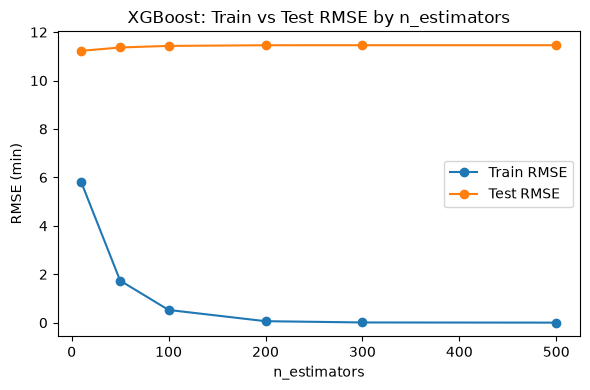

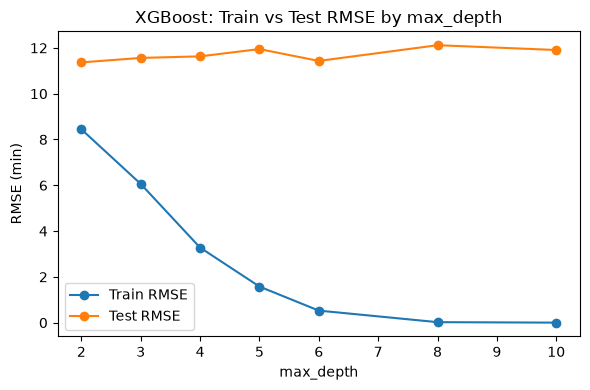

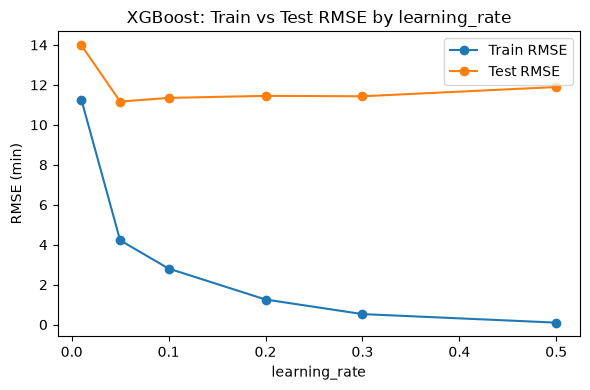

In [6]:
plot_train_test_error_curve(
    "XGBoost", _build_xgboost, "n_estimators",
    [10, 50, 100, 200, 300, 500], X_train_native, X_test_native,
)
plot_train_test_error_curve(
    "XGBoost", _build_xgboost, "max_depth",
    [2, 3, 4, 5, 6, 8, 10], X_train_native, X_test_native,
)
plot_train_test_error_curve(
    "XGBoost", _build_xgboost, "learning_rate",
    [0.01, 0.05, 0.1, 0.2, 0.3, 0.5], X_train_native, X_test_native,
)

## CatBoost

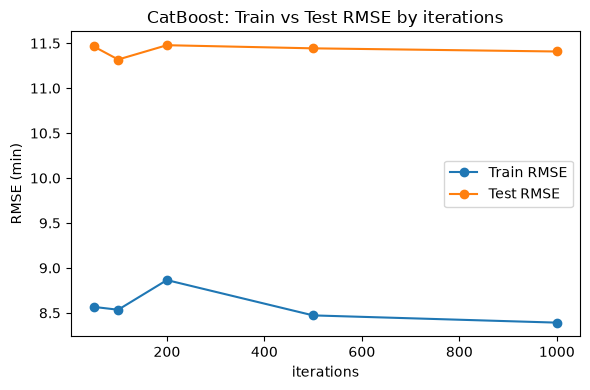

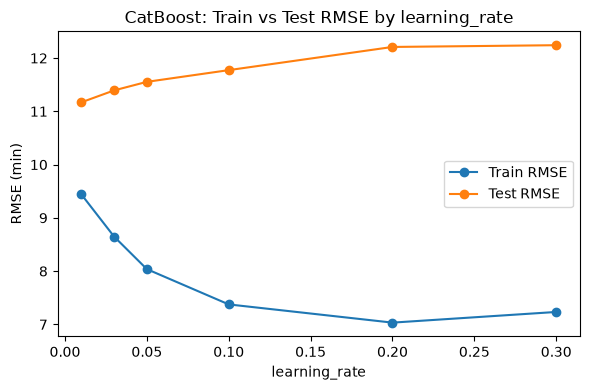

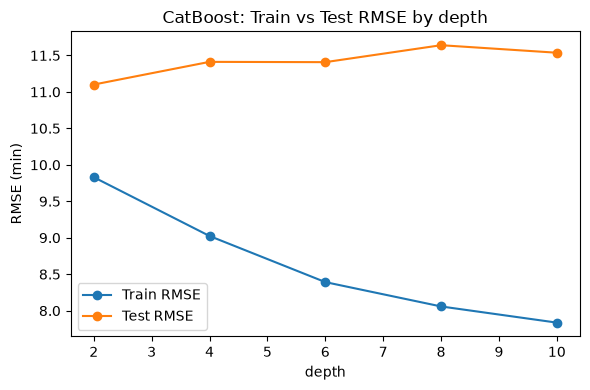

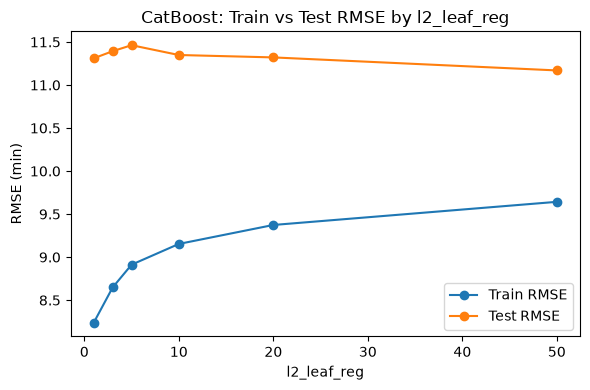

In [7]:
plot_train_test_error_curve(
    "CatBoost", _build_catboost, "iterations",
    [50, 100, 200, 500, 1000], X_train_native, X_test_native,
)
plot_train_test_error_curve(
    "CatBoost", _build_catboost, "learning_rate",
    [0.01, 0.03, 0.05, 0.1, 0.2, 0.3], X_train_native, X_test_native,
)
plot_train_test_error_curve(
    "CatBoost", _build_catboost, "depth",
    [2, 4, 6, 8, 10], X_train_native, X_test_native,
)
plot_train_test_error_curve(
    "CatBoost", _build_catboost, "l2_leaf_reg",
    [1, 3, 5, 10, 20, 50], X_train_native, X_test_native,
)

## Lasso Regression

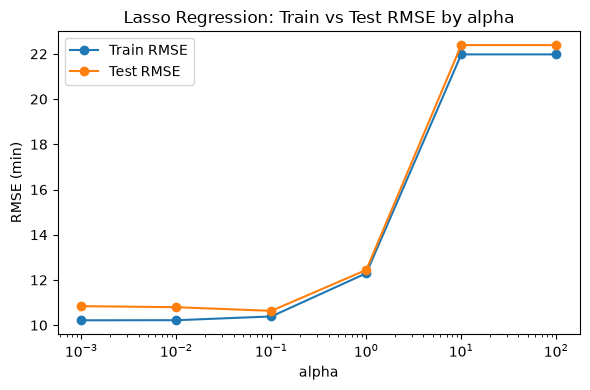

In [8]:
plot_train_test_error_curve(
    "Lasso Regression", _build_lasso, "alpha",
    [0.001, 0.01, 0.1, 1, 10, 100], X_train_encoded, X_test_encoded,
    log_x=True,
)